# 00 — Configuração do ambiente
## Análise Exploratória de Dados sobre a Incidência de Dengue em Santa Catarina

Este notebook apresenta uma Análise Exploratória de Dados (EDA) sobre
a incidência de dengue nos municípios do estado de Santa Catarina.

A análise considera o período de 2015 a 2025, utilizando dados
públicos disponibilizados pela API do InfoDengue (Fiocruz/UFMG), que
consolida notificações originadas do Sistema de Informação de
Agravos de Notificação (SINAN) do Ministério da Saúde (ver seção 4.1
para o histórico dessa escolha de fonte).

Posteriormente, os dados epidemiológicos serão relacionados com
informações climáticas, demográficas e socioeconômicas provenientes
de bases públicas brasileiras, buscando investigar fatores
possivelmente associados à incidência de dengue.


In [25]:
%pip install requests pandas matplotlib
print("Dependências instaladas/verificadas: requests, pandas, matplotlib")

Note: you may need to restart the kernel to use updated packages.
Dependências instaladas/verificadas: requests, pandas, matplotlib


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import requests
import time

from datetime import datetime

print("Bibliotecas importadas: pandas, numpy, matplotlib, requests, time, datetime")

Bibliotecas importadas: pandas, numpy, matplotlib, requests, time, datetime


## 0.1 Configuração central de variáveis

Todas as variáveis usadas no restante do notebook (UF, período,
endpoints, caminhos de arquivo, parâmetros de requisição) são
definidas uma única vez aqui. O resto do notebook só referencia essas
constantes.

In [27]:
# --- Escopo geográfico ---
UF_SIGLA = "SC"
UF_CODIGO_IBGE = 42

# --- Escopo temporal ---
EY_INICIO = 2015
EY_FIM = 2025

# --- Doença analisada ---
DOENCA = "dengue"

# --- Diretórios de dados ---
DIR_RAW = "../data/raw"
DIR_PROCESSED = "../data/processed"

# --- Endpoints e identificadores das APIs ---
URL_IBGE_LOCALIDADES = (
    f"https://servicodados.ibge.gov.br/api/v1/localidades/estados/{UF_SIGLA}/municipios"
)
URL_INFODENGUE = "https://info.dengue.mat.br/api/alertcity"
IBGE_TABELA_POPULACAO = 6579
IBGE_VARIAVEL_POPULACAO = 9324
IBGE_TABELA_AREA = 1301
IBGE_VARIAVEL_AREA = 615
URL_INMET_ZIP = "https://portal.inmet.gov.br/uploads/dadoshistoricos/{ano}.zip"  # download manual, seção 4.3
URL_ANA_DOWNLOAD = "https://dadosabertos.ana.gov.br/api/download/v1/items/{item_id}/csv?layers={layer}"
ANA_ETE_ITEM_ID = "0ac689335d1641d2b88a32312d22c9ac"  # Atlas Esgotos ETE 2020 (ANA)
ANA_ETE_LAYER = 0

# --- Arquivos gerados/consumidos pelo pipeline ---
ARQ_DENGUE_SEMANAL = f"{DIR_RAW}/infodengue_sc_{EY_INICIO}_{EY_FIM}.csv"
ARQ_DENGUE_MENSAL = f"{DIR_PROCESSED}/dengue_clima_sc_mensal.csv"
ARQ_POPULACAO = f"{DIR_PROCESSED}/populacao_sc.csv"
ARQ_AREA = f"{DIR_PROCESSED}/area_sc.csv"
ARQ_PRECIPITACAO_MENSAL = f"{DIR_PROCESSED}/precipitacao_sc_mensal.csv"
ARQ_SNIS_RAW = f"{DIR_RAW}/snis_serie_historica.csv"
ARQ_SANEAMENTO = f"{DIR_PROCESSED}/saneamento_sc.csv"
ARQ_BASE_ANALITICA = f"{DIR_PROCESSED}/base_analitica_sc.csv"

# --- Parâmetros de requisição HTTP ---
TIMEOUT_REQUISICAO = 60
MAX_TENTATIVAS = 3
PAUSA_ENTRE_REQUISICOES = 0.1

# --- Opções de exibição do pandas ---
PANDAS_MAX_COLUNAS = None
PANDAS_MAX_LINHAS = 100

print("Configuração central carregada:")
print(f"  UF: {UF_SIGLA} (código IBGE {UF_CODIGO_IBGE})")
print(f"  Período: {EY_INICIO}-{EY_FIM}")
print(f"  Doença: {DOENCA}")
print(f"  Diretórios: {DIR_RAW} | {DIR_PROCESSED}")

Configuração central carregada:
  UF: SC (código IBGE 42)
  Período: 2015-2025
  Doença: dengue
  Diretórios: ../data/raw | ../data/processed


In [28]:
pd.set_option("display.max_columns", PANDAS_MAX_COLUNAS)
pd.set_option("display.max_rows", PANDAS_MAX_LINHAS)

print(f"Opções de exibição do pandas configuradas: max_columns={PANDAS_MAX_COLUNAS}, "
      f"max_rows={PANDAS_MAX_LINHAS}")

Opções de exibição do pandas configuradas: max_columns=None, max_rows=100


# 1. Introdução

A dengue é uma doença viral transmitida principalmente pela picada
da fêmea infectada do mosquito *Aedes aegypti*.

A ocorrência da doença não depende exclusivamente da presença do
vetor, podendo apresentar relações com diferentes características
ambientais, climáticas, demográficas e socioeconômicas.

Dessa forma, este trabalho propõe a realização de uma análise
exploratória dos registros de dengue em Santa Catarina, buscando
identificar padrões espaciais e temporais da doença e investigar
possíveis associações entre sua incidência e diferentes
características dos municípios.

A análise exploratória constitui uma etapa inicial do projeto e
servirá como base para a seleção de variáveis que poderão ser
posteriormente utilizadas na construção de modelos de Machine
Learning.

## 2.1 Objetivo geral

Analisar a incidência de dengue nos municípios de Santa Catarina
entre 2015 e 2025, buscando identificar padrões temporais e espaciais
e investigar possíveis associações com fatores climáticos,
demográficos e socioeconômicos.

## 2.2 Objetivos específicos

- Analisar a evolução histórica dos registros de dengue em Santa Catarina;

- identificar padrões sazonais na ocorrência da doença;

- comparar a incidência de dengue entre os municípios catarinenses;

- investigar possíveis relações entre temperatura, precipitação,
  umidade e incidência de dengue;

- investigar possíveis relações entre características demográficas
  e socioeconômicas dos municípios e a incidência da doença;

- avaliar a influência de informações temporais anteriores,
  como casos e condições climáticas dos meses anteriores;

- identificar variáveis candidatas para utilização posterior em
  modelos de Machine Learning.

# 3. Hipóteses de pesquisa

A partir das características biológicas do *Aedes aegypti* e dos
fatores potencialmente relacionados à transmissão da dengue,
serão investigadas as seguintes hipóteses:

**H1 — Sazonalidade**

A incidência de dengue apresenta comportamento sazonal ao longo
dos meses do ano.

**H2 — Temperatura**

A temperatura apresenta associação com a incidência de dengue.

**H3 — Precipitação**

A precipitação observada em períodos anteriores apresenta
associação com a incidência posterior de dengue.

**H4 — Umidade**

A umidade relativa do ar apresenta associação com a incidência
da doença.

**H5 — Densidade demográfica**

Municípios com diferentes níveis de densidade demográfica
apresentam padrões distintos de incidência de dengue.

**H6 — Condições socioeconômicas**

Características socioeconômicas e de infraestrutura urbana
apresentam associação com diferenças na incidência entre
municípios.

**H7 — Dependência temporal**

A incidência observada nos meses anteriores apresenta relação
com a incidência observada no mês atual.

# 4. Fontes dos dados

## 4.1 InfoDengue (Fiocruz/UFMG)

Os registros epidemiológicos de dengue utilizados neste estudo serão
obtidos a partir da API do InfoDengue, que disponibiliza dados por
município e semana epidemiológica, já enriquecidos com clima e
população (nota completa sobre a mudança de fonte logo abaixo).

Os dados serão utilizados para construir uma base agregada com
granularidade:

**município de residência × mês**

O recorte geográfico principal será o estado de Santa Catarina, com
período inicial de 2015 a 2025.

In [29]:
import os

os.makedirs(DIR_RAW, exist_ok=True)
os.makedirs(DIR_PROCESSED, exist_ok=True)

print(f"Diretórios prontos: {DIR_RAW} e {DIR_PROCESSED}")

Diretórios prontos: ../data/raw e ../data/processed


In [30]:
def municipios_sc():
    """Lista os 295 municípios de SC via API do IBGE (código de 7 dígitos,
    usado como 'geocode' pela API do InfoDengue). Inclui a microrregião,
    usada na seção 4.3 para associar município à estação do INMET."""
    resp = requests.get(URL_IBGE_LOCALIDADES, timeout=TIMEOUT_REQUISICAO)
    resp.raise_for_status()
    return [
        {
            "codigo_ibge": m["id"],
            "nome": m["nome"],
            "microrregiao_id": m["microrregiao"]["id"],
        }
        for m in resp.json()
    ]


print(f"Consultando lista de municípios de {UF_SIGLA} na API do IBGE...")
sc_municipios = municipios_sc()
print(f"Concluído: {len(sc_municipios)} municípios de {UF_SIGLA} carregados.")

Consultando lista de municípios de SC na API do IBGE...
Concluído: 295 municípios de SC carregados.


A **API InfoDengue** (Fiocruz/UFMG) fornece dados consolidados de dengue no Brasil. Uma única requisição por município retorna **casos, incidência por 100 mil habitantes, população, temperatura e umidade** para toda a série histórica disponível. O filtro direto por `geocode` (código IBGE de 7 dígitos) simplifica as consultas, e os dados meteorológicos já estão integrados. Os dados históricos começam aproximadamente em **2010** (com variação conforme o município) e a API também suporta `disease=chikungunya` e `disease=zika` para futuras expansões do escopo.

In [31]:
def coletar_infodengue(municipios, disease=DOENCA, ey_inicio=EY_INICIO,
                        ey_fim=EY_FIM, max_tentativas=MAX_TENTATIVAS,
                        pausa=PAUSA_ENTRE_REQUISICOES):
    """Coleta a série semanal do InfoDengue para os municípios informados.
    Uma chamada por município já cobre todo o intervalo de anos.
    """
    registros = []
    t_inicio = time.time()
    params_base = {
        "disease": disease,
        "format": "json",
        "ew_start": 1,
        "ew_end": 52,
        "ey_start": ey_inicio,
        "ey_end": ey_fim,
    }
    for i, m in enumerate(municipios, start=1):
        params = {**params_base, "geocode": m["codigo_ibge"]}

        r = None
        for tentativa in range(1, max_tentativas + 1):
            try:
                r = requests.get(URL_INFODENGUE, params=params, timeout=TIMEOUT_REQUISICAO)
                break
            except requests.RequestException as e:
                print(f"  [ERRO] municipio={m['nome']} tentativa={tentativa}/{max_tentativas}: {e}")
                if tentativa < max_tentativas:
                    time.sleep(2 * tentativa)

        if r is None:
            print(f"  [ABORTADO] municipio={m['nome']} — sem resposta, pulando.")
            continue
        if r.status_code != 200:
            print(f"  [AVISO] municipio={m['nome']} status={r.status_code}")
            continue

        semanas = r.json()
        for reg in semanas:
            reg["nome_municipio"] = m["nome"]
            reg["codigo_ibge"] = m["codigo_ibge"]
        registros.extend(semanas)

        if i % 25 == 0 or i == len(municipios):
            decorrido = time.time() - t_inicio
            print(f"  ... {i}/{len(municipios)} municípios processados "
                  f"({decorrido:.0f}s decorridos, {len(registros)} registros até agora)")

        time.sleep(pausa)

    return pd.DataFrame(registros)


print(f"Função coletar_infodengue() definida. Endpoint: {URL_INFODENGUE}")
print(f"Período configurado: {EY_INICIO} a {EY_FIM} (doença: {DOENCA})")

Função coletar_infodengue() definida. Endpoint: https://info.dengue.mat.br/api/alertcity
Período configurado: 2015 a 2025 (doença: dengue)


In [32]:
print(f"Verificando se já existe coleta salva em {ARQ_DENGUE_SEMANAL}...")
if os.path.exists(ARQ_DENGUE_SEMANAL):
    df_dengue_semanal = pd.read_csv(ARQ_DENGUE_SEMANAL)
    print(f"Já coletado — lidos {len(df_dengue_semanal)} registros semanais de {ARQ_DENGUE_SEMANAL}")
else:
    print(f"Nada em cache. Coletando via InfoDengue para {len(sc_municipios)} municípios de {UF_SIGLA}...")
    df_dengue_semanal = coletar_infodengue(sc_municipios)
    df_dengue_semanal.to_csv(ARQ_DENGUE_SEMANAL, index=False)
    print(f"Concluído: {len(df_dengue_semanal)} registros semanais coletados e salvos em {ARQ_DENGUE_SEMANAL}")

df_dengue_semanal.head()

Verificando se já existe coleta salva em ../data/raw/infodengue_sc_2015_2025.csv...
Já coletado — lidos 169035 registros semanais de ../data/raw/infodengue_sc_2015_2025.csv


,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,id,versao_modelo,municipio_nome,Rt,pop,tempmin,umidmax,receptivo,transmissao,nivel_inc,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year,nome_municipio,codigo_ibge
0,1766275200000,202552,0.0,0,0,0,0.5,0.0,0,1,420005120255220698,2026-09-02,Abdon Batista,0.0,2600,20.001200,94.461586,0,0,0,81.442286,61.330000,23.319900,27.638414,0,NaN,NaN,NaN,NaN,2,Abdon Batista,4200051
1,1765670400000,202551,0.0,0,0,0,0.5,0.0,0,1,420005120255120698,2026-09-02,Abdon Batista,0.0,2600,15.367686,91.991514,0,0,0,70.779286,47.196371,20.668971,26.325371,0,NaN,NaN,NaN,NaN,2,Abdon Batista,4200051
2,1765065600000,202550,0.0,0,0,0,0.5,0.0,0,1,420005120255020698,2026-09-02,Abdon Batista,0.0,2600,15.509129,93.741614,0,0,0,77.517214,58.654900,19.707343,23.909957,0,NaN,NaN,NaN,NaN,2,Abdon Batista,4200051
3,1764460800000,202549,0.0,0,0,0,0.5,0.0,0,1,420005120254920698,2026-09-02,Abdon Batista,0.0,2600,16.428429,93.722843,0,0,0,73.586000,52.219757,21.142557,26.005900,0,NaN,NaN,NaN,NaN,2,Abdon Batista,4200051
4,1763856000000,202548,0.0,0,0,0,0.5,0.0,0,1,420005120254820698,2026-09-02,Abdon Batista,0.0,2600,14.991700,92.354114,0,0,0,76.787543,57.969657,19.089114,23.446786,0,NaN,NaN,NaN,NaN,2,Abdon Batista,4200051


In [33]:
df_dengue_semanal["data_semana"] = pd.to_datetime(df_dengue_semanal["data_iniSE"], unit="ms")
df_dengue_semanal["ano_mes"] = df_dengue_semanal["data_semana"].dt.to_period("M")

colunas_numericas = [
    "casos", "casos_est", "pop", "p_inc100k",
    "tempmin", "tempmed", "tempmax",
    "umidmin", "umidmed", "umidmax",
]
for col in colunas_numericas:
    df_dengue_semanal[col] = pd.to_numeric(df_dengue_semanal[col], errors="coerce")

print(f"Agregando {len(df_dengue_semanal)} registros semanais para granularidade município x mês...")

df_dengue_mensal = (
    df_dengue_semanal
    .groupby(["codigo_ibge", "nome_municipio", "ano_mes"])
    .agg(
        casos=("casos", "sum"),
        casos_est=("casos_est", "sum"),
        populacao=("pop", "last"),
        incidencia_100k=("p_inc100k", "mean"),
        temperatura_media=("tempmed", "mean"),
        temperatura_min=("tempmin", "mean"),
        temperatura_max=("tempmax", "mean"),
        umidade_media=("umidmed", "mean"),
        umidade_min=("umidmin", "mean"),
        umidade_max=("umidmax", "mean"),
    )
    .reset_index()
)
df_dengue_mensal.to_csv(ARQ_DENGUE_MENSAL, index=False)

print(f"Concluído: {len(df_dengue_mensal)} linhas (município x mês) salvas em {ARQ_DENGUE_MENSAL}")
print(f"Período coberto: {df_dengue_mensal['ano_mes'].min()} a {df_dengue_mensal['ano_mes'].max()}")
print(f"Municípios distintos: {df_dengue_mensal['codigo_ibge'].nunique()}")

df_dengue_mensal.head()

Agregando 169035 registros semanais para granularidade município x mês...
Concluído: 38940 linhas (município x mês) salvas em ../data/processed/dengue_clima_sc_mensal.csv
Período coberto: 2015-01 a 2025-12
Municípios distintos: 295


,codigo_ibge,nome_municipio,ano_mes,casos,casos_est,populacao,incidencia_100k,temperatura_media,temperatura_min,temperatura_max,umidade_media,umidade_min,umidade_max
0,4200051,Abdon Batista,2015-01,0,0.0,2548,0.0,23.836998,19.142857,27.464286,74.300814,52.750000,93.071429
1,4200051,Abdon Batista,2015-02,0,0.0,2548,0.0,23.059136,18.785714,26.964286,73.865558,52.892857,91.214286
2,4200051,Abdon Batista,2015-03,0,0.0,2548,0.0,23.006678,17.771429,27.514286,72.221561,42.857143,91.942857
3,4200051,Abdon Batista,2015-04,0,0.0,2548,0.0,20.115107,14.928571,24.214286,75.293491,47.107143,92.714286
4,4200051,Abdon Batista,2015-05,0,0.0,2548,0.0,17.419905,13.000000,21.314286,74.109648,56.514286,91.057143


## 4.2 IBGE — Estimativas de População (Demografia)

Fonte: tabela [6579 — População residente estimada](https://sidra.ibge.gov.br/tabela/6579)
do SIDRA/IBGE, série anual (2001–2026), nível município. Diferente do
SINAN, essa API filtra diretamente por UF, então uma única chamada
por ano já traz os 295 municípios de SC.

In [34]:
def populacao_sc(anos):
    registros = []
    for ano in anos:
        url = (
            f"https://servicodados.ibge.gov.br/api/v3/agregados/{IBGE_TABELA_POPULACAO}"
            f"/periodos/{ano}/variaveis/{IBGE_VARIAVEL_POPULACAO}"
            f"?localidades=N6[N3[{UF_CODIGO_IBGE}]]"
        )
        r = requests.get(url, timeout=TIMEOUT_REQUISICAO)
        r.raise_for_status()
        resposta = r.json()

        if not resposta or not resposta[0].get("resultados"):
            print(f"  [AVISO] Ano {ano}: sem dados publicados pelo IBGE "
                  f"(provável lacuna do Censo 2022) — pulando.")
            continue

        series = resposta[0]["resultados"][0]["series"]
        for s in series:
            registros.append({
                "codigo_ibge": int(s["localidade"]["id"]),
                "municipio": s["localidade"]["nome"],
                "ano": ano,
                "populacao": int(s["serie"][str(ano)]),
            })
        print(f"  Ano {ano}: {len(series)} municípios coletados.")
    return pd.DataFrame(registros)


print(f"Consultando população estimada do IBGE (tabela {IBGE_TABELA_POPULACAO}) "
      f"para {EY_INICIO}-{EY_FIM}...")
df_populacao = populacao_sc(anos=range(EY_INICIO, EY_FIM + 1))
df_populacao.to_csv(ARQ_POPULACAO, index=False)
print(f"Concluído: {len(df_populacao)} registros (município x ano) salvos em {ARQ_POPULACAO}")

df_populacao.head()

Consultando população estimada do IBGE (tabela 6579) para 2015-2025...
  Ano 2015: 295 municípios coletados.
  Ano 2016: 295 municípios coletados.
  Ano 2017: 295 municípios coletados.
  Ano 2018: 295 municípios coletados.
  Ano 2019: 295 municípios coletados.
  Ano 2020: 295 municípios coletados.
  Ano 2021: 295 municípios coletados.
  [AVISO] Ano 2022: sem dados publicados pelo IBGE (provável lacuna do Censo 2022) — pulando.
  [AVISO] Ano 2023: sem dados publicados pelo IBGE (provável lacuna do Censo 2022) — pulando.
  Ano 2024: 295 municípios coletados.
  Ano 2025: 295 municípios coletados.
Concluído: 2655 registros (município x ano) salvos em ../data/processed/populacao_sc.csv


,codigo_ibge,municipio,ano,populacao
0,4200051,Abdon Batista - SC,2015,2630
1,4200101,Abelardo Luz - SC,2015,17717
2,4200200,Agrolândia - SC,2015,10272
3,4200309,Agronômica - SC,2015,5306
4,4200408,Água Doce - SC,2015,7132


### 4.2.1 IBGE — Área territorial (para densidade demográfica, H5)

Fonte: tabela [1301 — Área e Densidade demográfica da unidade territorial](https://sidra.ibge.gov.br/tabela/1301)
do SIDRA/IBGE. Só existe o período de 2010 (a área de um município
muda muito pouco ao longo do tempo, então o IBGE não republica isso
todo ano) — tratamos como valor fixo por município.

In [35]:
def area_sc():
    url = (
        f"https://servicodados.ibge.gov.br/api/v3/agregados/{IBGE_TABELA_AREA}"
        f"/periodos/2010/variaveis/{IBGE_VARIAVEL_AREA}"
        f"?localidades=N6[N3[{UF_CODIGO_IBGE}]]"
    )
    r = requests.get(url, timeout=TIMEOUT_REQUISICAO)
    r.raise_for_status()
    series = r.json()[0]["resultados"][0]["series"]
    registros = [
        {
            "codigo_ibge": int(s["localidade"]["id"]),
            "area_km2": float(s["serie"]["2010"]),
        }
        for s in series
        if s["serie"]["2010"] not in (None, "-", "...")
    ]
    return pd.DataFrame(registros)


print(f"Consultando área territorial do IBGE (tabela {IBGE_TABELA_AREA})...")
df_area = area_sc()
df_area.to_csv(ARQ_AREA, index=False)
print(f"Concluído: {len(df_area)} municípios com área salvos em {ARQ_AREA} "
      f"(de {len(sc_municipios)} municípios de {UF_SIGLA} — nem todo município "
      f"tem área publicada na tabela 2010, ex.: municípios criados depois).")

df_area.head()

Consultando área territorial do IBGE (tabela 1301)...


Concluído: 293 municípios com área salvos em ../data/processed/area_sc.csv (de 295 municípios de SC — nem todo município tem área publicada na tabela 2010, ex.: municípios criados depois).


,codigo_ibge,area_km2
0,4200051,235.6
1,4200101,955.4
2,4200200,207.1
3,4200309,130.0
4,4200408,1313.0


## 4.3 INMET — Precipitação (complementar)

O InfoDengue (seção 4.1) já cobre temperatura e umidade. A única
variável climática que falta é **precipitação**, necessária para a
H3 — o InfoDengue não a disponibiliza.

Os "Dados Históricos" do INMET não têm API de consulta — são
arquivos estáticos, um zip por ano com todas as estações do Brasil.
O download é automatizado pela célula abaixo (o portal bloqueia o
User-Agent padrão de bibliotecas HTTP, por isso o header
`User-Agent` explícito). As 24 estações automáticas de SC (ex.: A806
Florianópolis, A895 Chapecó, A865 Lages) aparecem nos arquivos
nomeados `INMET_S_SC_<codigo>_<cidade>_..._.CSV` dentro de cada zip.

Seção opcional — sem os zips, só a H3 fica sem teste.

In [36]:
import zipfile


def baixar_inmet_zip(ano, destino, max_tentativas=MAX_TENTATIVAS):
    """Baixa o zip de Dados Históricos do INMET para um ano.
    """
    url = URL_INMET_ZIP.format(ano=ano)
    headers = {"User-Agent": "Mozilla/5.0"}
    for tentativa in range(1, max_tentativas + 1):
        try:
            with requests.get(url, headers=headers, timeout=300, stream=True) as r:
                r.raise_for_status()
                with open(destino, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
        except requests.RequestException as e:
            print(f"    [ERRO] tentativa {tentativa}/{max_tentativas}: {e}")
            continue

        if zipfile.is_zipfile(destino):
            return True
        print(f"    [AVISO] zip inválido/incompleto na tentativa {tentativa}/{max_tentativas}, tentando de novo...")
        if os.path.exists(destino):
            os.remove(destino)
    return False


print(f"Baixando zips do INMET para {EY_INICIO}-{EY_FIM} (pulando os que já existem e são válidos)...")
for ano in range(EY_INICIO, EY_FIM + 1):
    destino = f"{DIR_RAW}/{ano}.zip"
    if os.path.exists(destino) and zipfile.is_zipfile(destino):
        print(f"  {ano}: já existe e é válido, pulando.")
        continue
    print(f"  {ano}: baixando de {URL_INMET_ZIP.format(ano=ano)}...")
    ok = baixar_inmet_zip(ano, destino)
    tamanho_mb = os.path.getsize(destino) / 1e6 if os.path.exists(destino) else 0
    print(f"  {ano}: {'OK' if ok else 'FALHOU (todas as tentativas)'} ({tamanho_mb:.0f} MB)")

Baixando zips do INMET para 2015-2025 (pulando os que já existem e são válidos)...
  2015: já existe e é válido, pulando.
  2016: já existe e é válido, pulando.
  2017: já existe e é válido, pulando.
  2018: já existe e é válido, pulando.
  2019: já existe e é válido, pulando.
  2020: já existe e é válido, pulando.
  2021: já existe e é válido, pulando.
  2022: já existe e é válido, pulando.
  2023: já existe e é válido, pulando.
  2024: já existe e é válido, pulando.
  2025: já existe e é válido, pulando.


In [37]:
import zipfile
import io


def parse_inmet_zip(caminho_zip):
    """Lê um zip de Dados Históricos do INMET e retorna um DataFrame
    só com as estações de Santa Catarina (nome do arquivo contém
    '_SC_')
    """
    marcador_uf = f"_{UF_SIGLA}_"
    partes = []
    with zipfile.ZipFile(caminho_zip) as z:
        nomes_sc = [n for n in z.namelist() if marcador_uf in n]
        for nome in nomes_sc:
            with z.open(nome) as f:
                linhas = f.read().decode("latin-1").splitlines()

            metadados = dict(l.split(";", 1) for l in linhas[:8] if ";" in l)
            codigo_estacao = metadados.get("CODIGO (WMO):", "").strip()
            nome_estacao = metadados.get("ESTAÇÃO:", "").strip()

            df = pd.read_csv(
                io.StringIO("\n".join(linhas[8:])),
                sep=";",
                decimal=",",
                na_values=["-9999", ""],
                encoding="latin-1",
            )
            df = df.rename(columns={"DATA (YYYY-MM-DD)": "DATA_STR", "Data": "DATA_STR"})
            df["codigo_estacao"] = codigo_estacao
            df["nome_estacao"] = nome_estacao
            partes.append(df)

    print(f"  {caminho_zip}: {len(nomes_sc)} estações de {UF_SIGLA} extraídas.")
    return pd.concat(partes, ignore_index=True)


print("Função parse_inmet_zip() definida.")

Função parse_inmet_zip() definida.


In [38]:
import unicodedata


def normalizar(texto):
    """Remove acentos e caixa, para comparar 'FLORIANOPOLIS' com 'Florianópolis'."""
    sem_acento = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    return sem_acento.strip().upper()


zips_clima = [
    f"{DIR_RAW}/{ano}.zip" for ano in range(EY_INICIO, EY_FIM + 1)
    if os.path.exists(f"{DIR_RAW}/{ano}.zip")
]
print(f"Zips do INMET encontrados em {DIR_RAW}/: {len(zips_clima)}")

if not zips_clima:
    print(f"Nenhum zip do INMET encontrado em {DIR_RAW}/ — seção opcional, "
          "necessária só para testar a H3 (precipitação).")
else:
    df_clima_bruto = pd.concat((parse_inmet_zip(z) for z in zips_clima), ignore_index=True)

    antes = len(df_clima_bruto)
    df_clima_bruto["data"] = pd.to_datetime(df_clima_bruto["DATA_STR"], format="mixed", errors="coerce")
    sem_data = df_clima_bruto["data"].isna().sum()
    if sem_data:
        print(f"  [AVISO] {sem_data}/{antes} linhas com data não reconhecida, serão descartadas da agregação.")
    df_clima_bruto["ano_mes"] = df_clima_bruto["data"].dt.to_period("M")

    df_precipitacao_mensal = (
        df_clima_bruto
        .groupby(["codigo_estacao", "nome_estacao", "ano_mes"])
        .agg(precipitacao_total=("PRECIPITAÇÃO TOTAL, HORÁRIO (mm)", "sum"))
        .reset_index()
    )
    df_precipitacao_mensal.to_csv(ARQ_PRECIPITACAO_MENSAL, index=False)
    print(f"Concluído: {len(df_precipitacao_mensal)} linhas (estação x mês) salvas em "
          f"{ARQ_PRECIPITACAO_MENSAL}")
    print(f"Período coberto: {df_precipitacao_mensal['ano_mes'].min()} a "
          f"{df_precipitacao_mensal['ano_mes'].max()}")

    estacoes = df_precipitacao_mensal[["codigo_estacao", "nome_estacao"]].drop_duplicates()
    nome_normalizado_para_municipio = {normalizar(m["nome"]): m for m in sc_municipios}

    estacao_para_municipio_sede = {}
    for _, row in estacoes.iterrows():
        candidatos = [row["nome_estacao"], row["nome_estacao"].split(" - ")[0]]
        m = next(
            (nome_normalizado_para_municipio[normalizar(c)]
             for c in candidatos if normalizar(c) in nome_normalizado_para_municipio),
            None,
        )
        if m is not None:
            estacao_para_municipio_sede[row["codigo_estacao"]] = m
        else:
            print(f"  [AVISO] estação {row['codigo_estacao']} ({row['nome_estacao']}): "
                  f"não encontrei município correspondente, fica de fora do mapeamento.")

    microrregiao_para_estacao = {
        m["microrregiao_id"]: codigo for codigo, m in estacao_para_municipio_sede.items()
    }

    mapeamento = []
    for m in sc_municipios:
        codigo_direto = next(
            (c for c, ms in estacao_para_municipio_sede.items() if ms["codigo_ibge"] == m["codigo_ibge"]),
            None,
        )
        if codigo_direto is not None:
            mapeamento.append({"codigo_ibge": m["codigo_ibge"], "codigo_estacao": codigo_direto, "tipo_match": "direto"})
        elif m["microrregiao_id"] in microrregiao_para_estacao:
            mapeamento.append({
                "codigo_ibge": m["codigo_ibge"],
                "codigo_estacao": microrregiao_para_estacao[m["microrregiao_id"]],
                "tipo_match": "microrregiao",
            })
        else:
            mapeamento.append({"codigo_ibge": m["codigo_ibge"], "codigo_estacao": None, "tipo_match": "sem_estacao"})

    df_mapeamento = pd.DataFrame(mapeamento)
    contagem = df_mapeamento["tipo_match"].value_counts()
    print(f"Associação município -> estação: "
          f"{contagem.get('direto', 0)} diretas, "
          f"{contagem.get('microrregiao', 0)} por microrregião, "
          f"{contagem.get('sem_estacao', 0)} sem estação (ficam sem precipitação).")

    df_precipitacao_municipio = (
        df_mapeamento.dropna(subset=["codigo_estacao"])
        .merge(df_precipitacao_mensal, on="codigo_estacao", how="left")
        [["codigo_ibge", "ano_mes", "precipitacao_total"]]
    )
    display(df_precipitacao_mensal.head())

Zips do INMET encontrados em ../data/raw/: 11
  ../data/raw/2015.zip: 21 estações de SC extraídas.
  ../data/raw/2016.zip: 22 estações de SC extraídas.
  ../data/raw/2017.zip: 22 estações de SC extraídas.
  ../data/raw/2018.zip: 22 estações de SC extraídas.
  ../data/raw/2019.zip: 24 estações de SC extraídas.
  ../data/raw/2020.zip: 24 estações de SC extraídas.
  ../data/raw/2021.zip: 24 estações de SC extraídas.
  ../data/raw/2022.zip: 24 estações de SC extraídas.
  ../data/raw/2023.zip: 24 estações de SC extraídas.
  ../data/raw/2024.zip: 24 estações de SC extraídas.
  ../data/raw/2025.zip: 24 estações de SC extraídas.
Concluído: 3054 linhas (estação x mês) salvas em ../data/processed/precipitacao_sc_mensal.csv
Período coberto: 2015-01 a 2025-12
  [AVISO] estação A806 (): não encontrei município correspondente, fica de fora do mapeamento.
  [AVISO] estação A814 (): não encontrei município correspondente, fica de fora do mapeamento.
  [AVISO] estação A815 (): não encontrei município c

,codigo_estacao,nome_estacao,ano_mes,precipitacao_total
0,A806,,2019-01,225.2
1,A806,,2019-02,257.2
2,A806,,2019-03,82.6
3,A806,,2019-04,87.2
4,A806,,2019-05,156.6


## 4.4 ANA — Saneamento Básico (substitui o SNIS bloqueado)

O SNIS segue bloqueado (ver histórico abaixo), mas achamos uma fonte
alternativa real: o **Atlas Esgotos ETE 2020**, da ANA (Agência
Nacional de Águas e Saneamento Básico), disponível com download
direto em CSV — sem precisar de interface interativa:
[dadosabertos.ana.gov.br](https://dadosabertos.ana.gov.br/search).

Traz, por Estação de Tratamento de Esgoto (ETE), o status
(Ativa/Em construção/Não localizada), o município (código IBGE) e o
**percentual de remoção de DBO** — um proxy real de qualidade do
tratamento de esgoto, que usamos no lugar da "cobertura de
esgotamento sanitário" que viria do SNIS.

**Cobertura:** só 57 dos 295 municípios de SC têm alguma ETE
registrada neste Atlas — os demais ficam sem essa variável (NaN),
reportado explicitamente abaixo. Isso não significa necessariamente
"sem saneamento", só que não há ETE municipal catalogada nesta base.

---

*Histórico do SNIS (bloqueado em 2026-09-10):* o link antigo do SNIS
estava quebrado e migrou nominalmente para o Ministério das Cidades,
mas `app4.mdr.gov.br` está com **DNS fora do ar** (`NXDOMAIN`), e os
catálogos oficiais (dados.gov.br, dadosabertos.cidades.gov.br) só
apontam de volta para esse mesmo aplicativo, sem arquivo em lote.

In [39]:
def carregar_saneamento_ana():
    """Baixa o Atlas Esgotos ETE 2020 (ANA) e agrega por município de
    SC: quantidade de ETEs ativas e remoção média de DBO (%).
    """
    url = URL_ANA_DOWNLOAD.format(item_id=ANA_ETE_ITEM_ID, layer=ANA_ETE_LAYER)
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=TIMEOUT_REQUISICAO)
    r.raise_for_status()

    from io import StringIO
    df = pd.read_csv(StringIO(r.text))
    df["ETE_MUN_CD_IBGE"] = df["ETE_MUN_CD_IBGE"].astype(str)
    df_sc = df[df["ETE_MUN_CD_IBGE"].str.startswith(str(UF_CODIGO_IBGE))].copy()
    df_ativas = df_sc[df_sc["ETE_DS_STATUS"] == "Ativa"].copy()
    df_ativas["ETE_PC_REMOCAODBO"] = pd.to_numeric(df_ativas["ETE_PC_REMOCAODBO"], errors="coerce")

    agregado = (
        df_ativas
        .groupby("ETE_MUN_CD_IBGE")
        .agg(
            qtd_ete_ativas=("ETE_CD", "count"),
            remocao_dbo_media=("ETE_PC_REMOCAODBO", "mean"),
        )
        .reset_index()
        .rename(columns={"ETE_MUN_CD_IBGE": "codigo_ibge"})
    )
    agregado["codigo_ibge"] = agregado["codigo_ibge"].astype(int)
    return agregado


print("Baixando Atlas Esgotos ETE 2020 (ANA)...")
df_saneamento = carregar_saneamento_ana()
df_saneamento.to_csv(ARQ_SANEAMENTO, index=False)
print(f"Concluído: {len(df_saneamento)} municípios de SC com ETE ativa "
      f"(de {len(sc_municipios)} no total) salvos em {ARQ_SANEAMENTO}")

df_saneamento.head()

Baixando Atlas Esgotos ETE 2020 (ANA)...
Concluído: 55 municípios de SC com ETE ativa (de 295 no total) salvos em ../data/processed/saneamento_sc.csv


,codigo_ibge,qtd_ete_ativas,remocao_dbo_media
0,4201307,2,0.850
1,4201604,1,0.820
2,4202008,1,0.950
3,4202404,2,0.875
4,4202453,1,0.850


# 5. Integração das Bases

Com o InfoDengue, dengue + temperatura + umidade + população já saem
juntos por município × mês (seção 4.1) — não é mais necessário o
merge manual entre SINAN, IBGE e INMET que fazíamos antes para essas
variáveis.

Nesta seção juntamos:
- **Área/densidade (IBGE, 4.2.1)** — sempre disponível;
- **Precipitação (INMET, 4.3)** — disponível para os municípios que
  puderam ser associados a uma estação (ver contagem impressa na
  seção 4.3: diretos, por microrregião, ou sem estação);
- **Saneamento (ANA, 4.4)** — disponível para os 57 municípios com
  ETE ativa registrada no Atlas Esgotos 2020; é um retrato fixo de
  2020 (não varia por ano/mês), por isso o merge usa só
  `codigo_ibge`, sem `ano`.

In [40]:
df_analitica = df_dengue_mensal.copy()
df_analitica["ano"] = df_analitica["ano_mes"].dt.year

df_analitica = df_analitica.merge(df_area, on="codigo_ibge", how="left")
df_analitica["densidade_demografica"] = df_analitica["populacao"] / df_analitica["area_km2"]

if "df_precipitacao_municipio" in globals():
    df_analitica = df_analitica.merge(
        df_precipitacao_municipio, on=["codigo_ibge", "ano_mes"], how="left"
    )
    cobertura = df_analitica["precipitacao_total"].notna().mean()
    print(f"Precipitação disponível em {cobertura:.0%} das linhas de df_analitica.")
else:
    print("Precipitação não mesclada — nenhum zip do INMET foi encontrado na seção 4.3.")

# Saneamento (ANA, seção 4.4): retrato fixo de 2020, não varia por ano/mês.
df_analitica = df_analitica.merge(df_saneamento, on="codigo_ibge", how="left")
cobertura_saneamento = df_analitica["remocao_dbo_media"].notna().mean()
print(f"Saneamento (ANA) disponível em {cobertura_saneamento:.0%} das linhas de df_analitica "
      f"({df_saneamento['codigo_ibge'].nunique()} de {len(sc_municipios)} municípios).")

df_analitica.to_csv(ARQ_BASE_ANALITICA, index=False)
print(f"Base analítica final: {len(df_analitica)} linhas, {df_analitica.shape[1]} colunas, "
      f"salva em {ARQ_BASE_ANALITICA}")
print(f"Colunas: {list(df_analitica.columns)}")

df_analitica.head()

Precipitação disponível em 92% das linhas de df_analitica.
Saneamento (ANA) disponível em 19% das linhas de df_analitica (55 de 295 municípios).
Base analítica final: 38940 linhas, 19 colunas, salva em ../data/processed/base_analitica_sc.csv
Colunas: ['codigo_ibge', 'nome_municipio', 'ano_mes', 'casos', 'casos_est', 'populacao', 'incidencia_100k', 'temperatura_media', 'temperatura_min', 'temperatura_max', 'umidade_media', 'umidade_min', 'umidade_max', 'ano', 'area_km2', 'densidade_demografica', 'precipitacao_total', 'qtd_ete_ativas', 'remocao_dbo_media']


,codigo_ibge,nome_municipio,ano_mes,casos,casos_est,populacao,incidencia_100k,temperatura_media,temperatura_min,temperatura_max,umidade_media,umidade_min,umidade_max,ano,area_km2,densidade_demografica,precipitacao_total,qtd_ete_ativas,remocao_dbo_media
0,4200051,Abdon Batista,2015-01,0,0.0,2548,0.0,23.836998,19.142857,27.464286,74.300814,52.750000,93.071429,2015,235.6,10.814941,161.4,NaN,NaN
1,4200051,Abdon Batista,2015-02,0,0.0,2548,0.0,23.059136,18.785714,26.964286,73.865558,52.892857,91.214286,2015,235.6,10.814941,222.8,NaN,NaN
2,4200051,Abdon Batista,2015-03,0,0.0,2548,0.0,23.006678,17.771429,27.514286,72.221561,42.857143,91.942857,2015,235.6,10.814941,136.6,NaN,NaN
3,4200051,Abdon Batista,2015-04,0,0.0,2548,0.0,20.115107,14.928571,24.214286,75.293491,47.107143,92.714286,2015,235.6,10.814941,73.2,NaN,NaN
4,4200051,Abdon Batista,2015-05,0,0.0,2548,0.0,17.419905,13.000000,21.314286,74.109648,56.514286,91.057143,2015,235.6,10.814941,80.8,NaN,NaN


# 6. Análise Exploratória — Verificação das Hipóteses

## 6.1 H1 — Sazonalidade

A incidência de dengue apresenta comportamento sazonal ao longo dos
meses do ano?

H1 — casos totais de dengue por mês do ano (somando todos os anos):
mes
1      39139
2     106117
3     290853
4     347668
5     235010
6      81957
7      29180
8      18013
9      19805
10     21965
11     26240
12     27067
Mês com mais casos: 4 (347668 casos)


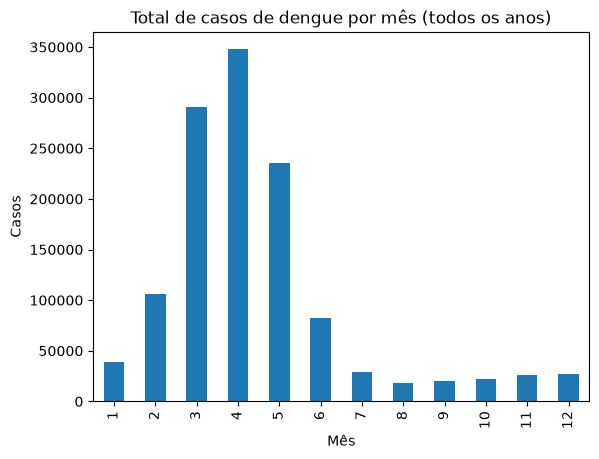

In [41]:
casos_por_mes = (
    df_analitica.assign(mes=df_analitica["ano_mes"].dt.month)
    .groupby("mes")["casos"].sum()
)
print("H1 — casos totais de dengue por mês do ano (somando todos os anos):")
print(casos_por_mes.to_string())
print(f"Mês com mais casos: {casos_por_mes.idxmax()} ({casos_por_mes.max()} casos)")

casos_por_mes.plot(kind="bar", title="Total de casos de dengue por mês (todos os anos)")
plt.xlabel("Mês")
plt.ylabel("Casos")
plt.show()

## 6.2 H2 — Temperatura

A temperatura apresenta associação com a incidência de dengue? Já
disponível diretamente em `df_analitica` (seção 4.1/5, via
InfoDengue).

H2 — correlação entre temperatura média mensal e incidência (100k hab.): 0.0065


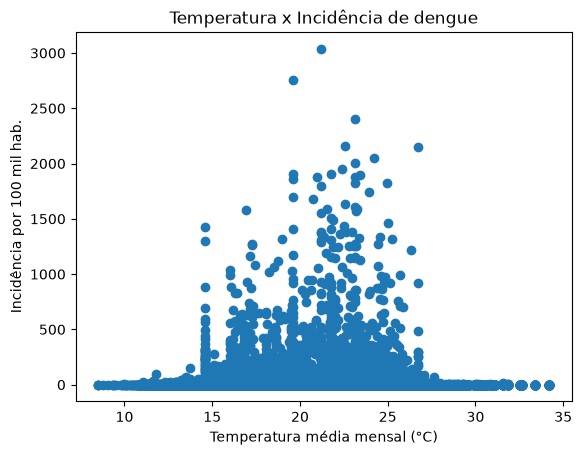

,temperatura_media,incidencia_100k
temperatura_media,1.000000,0.006529
incidencia_100k,0.006529,1.000000


In [42]:
corr_temp = df_analitica[["temperatura_media", "incidencia_100k"]].corr().iloc[0, 1]
print(f"H2 — correlação entre temperatura média mensal e incidência (100k hab.): {corr_temp:.4f}")

plt.scatter(df_analitica["temperatura_media"], df_analitica["incidencia_100k"])
plt.xlabel("Temperatura média mensal (°C)")
plt.ylabel("Incidência por 100 mil hab.")
plt.title("Temperatura x Incidência de dengue")
plt.show()

df_analitica[["temperatura_media", "incidencia_100k"]].corr()

## 6.3 H3 — Precipitação (defasada)

A precipitação de meses anteriores apresenta associação com a
incidência posterior — teste com `precipitacao_total` defasada em
1–2 meses (`shift`), já que o ciclo do vetor leva tempo para
responder à chuva.

H3 — correlação entre precipitação do mês anterior e incidência: 0.0065
(cobertura: 92% das linhas têm precipitação)


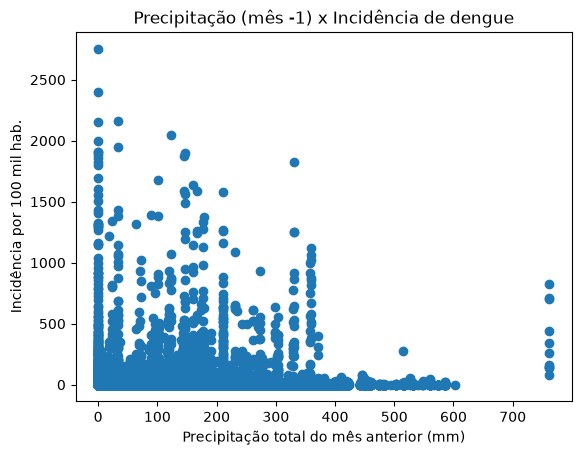

In [43]:
if "precipitacao_total" in df_analitica.columns and df_analitica["precipitacao_total"].notna().any():
    df_analitica = df_analitica.sort_values(["codigo_ibge", "ano_mes"])
    df_analitica["precipitacao_lag1"] = (
        df_analitica.groupby("codigo_ibge")["precipitacao_total"].shift(1)
    )
    corr_precip = df_analitica[["precipitacao_lag1", "incidencia_100k"]].corr().iloc[0, 1]
    print(f"H3 — correlação entre precipitação do mês anterior e incidência: {corr_precip:.4f}")
    print(f"(cobertura: {df_analitica['precipitacao_total'].notna().mean():.0%} das linhas têm precipitação)")

    plt.scatter(df_analitica["precipitacao_lag1"], df_analitica["incidencia_100k"])
    plt.xlabel("Precipitação total do mês anterior (mm)")
    plt.ylabel("Incidência por 100 mil hab.")
    plt.title("Precipitação (mês -1) x Incidência de dengue")
    plt.show()
else:
    print("H3 — pendente: nenhum município tem precipitação mesclada em df_analitica "
          "(nenhum zip do INMET encontrado em data/raw/, seção 4.3).")

## 6.4 H4 — Umidade

A umidade relativa do ar apresenta associação com a incidência da
doença? Já disponível diretamente em `df_analitica` (seção 4.1/5, via
InfoDengue).

H4 — correlação entre umidade relativa média mensal e incidência (100k hab.): 0.0475


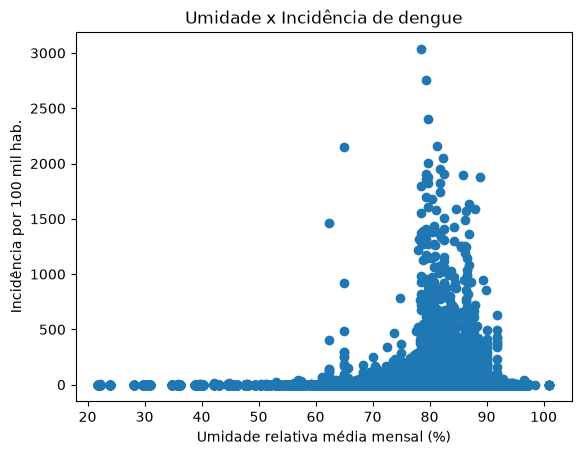

,umidade_media,incidencia_100k
umidade_media,1.000000,0.047486
incidencia_100k,0.047486,1.000000


In [44]:
corr_umid = df_analitica[["umidade_media", "incidencia_100k"]].corr().iloc[0, 1]
print(f"H4 — correlação entre umidade relativa média mensal e incidência (100k hab.): {corr_umid:.4f}")

plt.scatter(df_analitica["umidade_media"], df_analitica["incidencia_100k"])
plt.xlabel("Umidade relativa média mensal (%)")
plt.ylabel("Incidência por 100 mil hab.")
plt.title("Umidade x Incidência de dengue")
plt.show()

df_analitica[["umidade_media", "incidencia_100k"]].corr()

## 6.5 H5 — Densidade Demográfica

Municípios com diferentes níveis de densidade demográfica apresentam
padrões distintos de incidência? (densidade = população / área do
município — a área pode ser obtida na mesma API de localidades do
IBGE ou na tabela 1301 do SIDRA).

H5 — correlação entre densidade demográfica e incidência: 0.0727


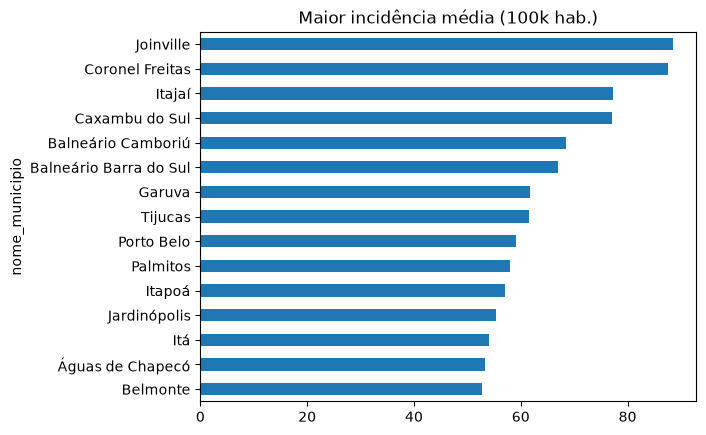

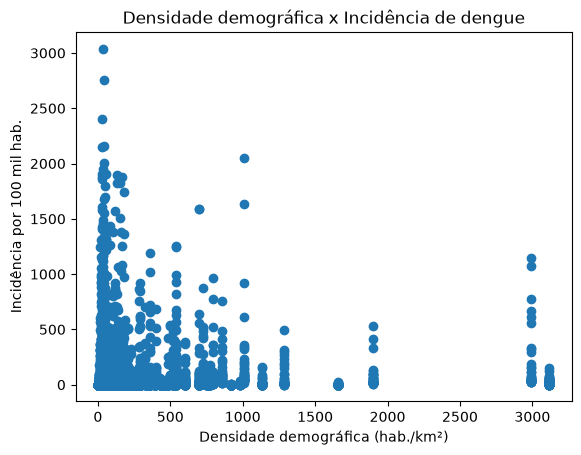

In [45]:
corr_dens = df_analitica[["densidade_demografica", "incidencia_100k"]].corr().iloc[0, 1]
print(f"H5 — correlação entre densidade demográfica e incidência: {corr_dens:.4f}")

incidencia_por_municipio = (
    df_analitica.groupby("nome_municipio")["incidencia_100k"].mean()
    .sort_values(ascending=False)
)
incidencia_por_municipio.head(15).plot(kind="barh", title="Maior incidência média (100k hab.)")
plt.gca().invert_yaxis()
plt.show()

plt.scatter(df_analitica["densidade_demografica"], df_analitica["incidencia_100k"])
plt.xlabel("Densidade demográfica (hab./km²)")
plt.ylabel("Incidência por 100 mil hab.")
plt.title("Densidade demográfica x Incidência de dengue")
plt.show()

## 6.6 H6 — Condições Socioeconômicas / Saneamento

A remoção de DBO (qualidade do tratamento de esgoto, via ETEs
ativas — Atlas Esgotos ANA 2020) apresenta associação com diferenças
na incidência entre municípios? Disponível só para os municípios com
ETE registrada (ver cobertura impressa na seção 5).

H6 — correlação entre remoção média de DBO e incidência: 0.0030
(cobertura: 19% das linhas)


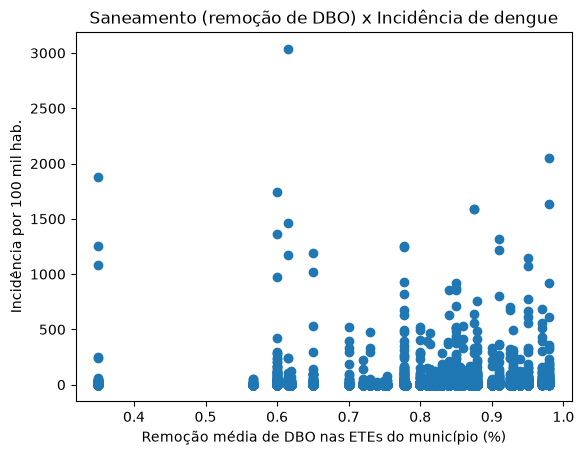

Incidência média — municípios COM ETE ativa registrada: 18.00
Incidência média — municípios SEM ETE ativa registrada: 12.10


In [46]:
if df_analitica["remocao_dbo_media"].notna().any():
    corr_saneamento = df_analitica[["remocao_dbo_media", "incidencia_100k"]].corr().iloc[0, 1]
    print(f"H6 — correlação entre remoção média de DBO e incidência: {corr_saneamento:.4f}")
    print(f"(cobertura: {df_analitica['remocao_dbo_media'].notna().mean():.0%} das linhas)")

    plt.scatter(df_analitica["remocao_dbo_media"], df_analitica["incidencia_100k"])
    plt.xlabel("Remoção média de DBO nas ETEs do município (%)")
    plt.ylabel("Incidência por 100 mil hab.")
    plt.title("Saneamento (remoção de DBO) x Incidência de dengue")
    plt.show()

    com_ete = df_analitica["qtd_ete_ativas"].notna()
    print(f"Incidência média — municípios COM ETE ativa registrada: "
          f"{df_analitica.loc[com_ete, 'incidencia_100k'].mean():.2f}")
    print(f"Incidência média — municípios SEM ETE ativa registrada: "
          f"{df_analitica.loc[~com_ete, 'incidencia_100k'].mean():.2f}")
else:
    print("H6 — sem dados de saneamento mesclados em df_analitica.")

## 6.7 H7 — Dependência Temporal

A incidência do mês anterior ajuda a explicar a incidência do mês
atual (autocorrelação)?

H7 — autocorrelação de casos mês a mês, município de exemplo: Abdon Batista (132 meses na série)


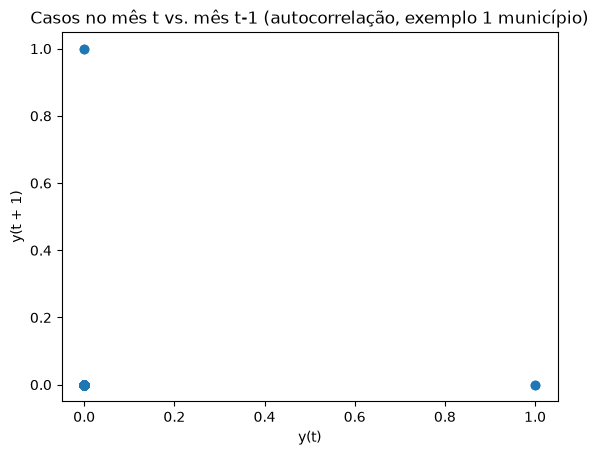

In [47]:
from pandas.plotting import lag_plot

codigo_exemplo = df_analitica["codigo_ibge"].iloc[0]
municipio_exemplo = df_analitica.loc[df_analitica["codigo_ibge"] == codigo_exemplo, "nome_municipio"].iloc[0]
serie_um_municipio = (
    df_analitica[df_analitica["codigo_ibge"] == codigo_exemplo]
    .sort_values("ano_mes")["casos"]
)
print(f"H7 — autocorrelação de casos mês a mês, município de exemplo: "
      f"{municipio_exemplo} ({len(serie_um_municipio)} meses na série)")

lag_plot(serie_um_municipio)
plt.title("Casos no mês t vs. mês t-1 (autocorrelação, exemplo 1 município)")
plt.show()